<a href="https://colab.research.google.com/github/tb267503/MIT725/blob/main/africa_population.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CAT1_tb267503**

Done By: TUMSIFU BALOLEBWAMI **BLAISE**

CUU: MIT 2025 SEMESTER 2

In [52]:
import pandas as pd
import numpy as np

# Load dataset
# The error "ParserError: Error tokenizing data. C error: Expected 7 fields in line 3, saw 8"
# suggests that the default comma delimiter might not be correct, or there are unescaped delimiters within the data.
# Trying to infer the separator using sep=None and engine='python' might resolve this.
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CAT1/afro/aficapop2.csv", sep=None, engine='python')

# Display first rows
df.head()

,﻿#,Country (or dependency),Population (2026),Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,Nigeria,"242,431,832",2.06%,"4,904,050",266,"910,77","−2,810",4.2,18,56%,2.92%
1,2,Ethiopia,"138,902,185",2.53%,"3,430,134",139,"1,000,000","27,298",3.7,19,23%,1.67%
2,3,Egypt,"120,101,175",1.47%,"1,735,180",121,"995,45","−52,287",2.7,25,41%,1.45%
3,4,DR Congo,"116,452,162",3.21%,"3,619,689",51,"2,267,050","−28,843",5.8,16,45%,1.40%
4,5,Tanzania,"72,563,780",2.86%,"2,017,915",82,"885,8","−25,275",4.4,18,41%,0.87%


In [53]:
# Display first rows
df.head()

# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ﻿#                       58 non-null     int64  
 1   Country (or dependency)  58 non-null     object 
 2   Population (2026)        58 non-null     object 
 3   Yearly Change            58 non-null     object 
 4   Net Change               58 non-null     object 
 5   Density (P/Km²)          58 non-null     int64  
 6   Land Area (Km²)          58 non-null     object 
 7   Migrants (net)           58 non-null     object 
 8   Fert. Rate               58 non-null     float64
 9   Median Age               58 non-null     int64  
 10  Urban Pop %              58 non-null     object 
 11  World Share              58 non-null     object 
dtypes: float64(1), int64(3), object(8)
memory usage: 5.6+ KB


In [54]:
# Check missing values
df.isnull().sum()

,0
﻿#,0
Country (or dependency),0
Population (2026),0
Yearly Change,0
Net Change,0
Density (P/Km²),0
Land Area (Km²),0
Migrants (net),0
Fert. Rate,0
Median Age,0


In [55]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [56]:
# Remove commas and convert numeric columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '', regex=False)

In [57]:
# Convert relevant columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# Drop rows with missing values (if necessary)
df = df.dropna()

/tmp/ipykernel_17391/2486441225.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [58]:
# Reset index
df.reset_index(drop=True, inplace=True)

# Final check
df.head()

,﻿#,Country_(or_dependency),Population_(2026),Yearly_Change,Net_Change,Density_(P/Km²),Land_Area_(Km²),Migrants_(net),Fert._Rate,Median_Age,Urban_Pop_%,World_Share
0,1,Nigeria,242431832,2.06%,4904050,266,91077,−2810,4.2,18,56%,2.92%
1,2,Ethiopia,138902185,2.53%,3430134,139,1000000,27298,3.7,19,23%,1.67%
2,3,Egypt,120101175,1.47%,1735180,121,99545,−52287,2.7,25,41%,1.45%
3,4,DR Congo,116452162,3.21%,3619689,51,2267050,−28843,5.8,16,45%,1.40%
4,5,Tanzania,72563780,2.86%,2017915,82,8858,−25275,4.4,18,41%,0.87%


In [59]:
# Supprimer la colonne '#' si elle existe
if '#' in df.columns:
    df.drop(columns=['#'], inplace=True)

In [60]:
# Réinitialiser l'index en commençant par 1
df.index = range(1, len(df) + 1)

In [61]:
# Vérifier
df.head()

,﻿#,Country_(or_dependency),Population_(2026),Yearly_Change,Net_Change,Density_(P/Km²),Land_Area_(Km²),Migrants_(net),Fert._Rate,Median_Age,Urban_Pop_%,World_Share
1,1,Nigeria,242431832,2.06%,4904050,266,91077,−2810,4.2,18,56%,2.92%
2,2,Ethiopia,138902185,2.53%,3430134,139,1000000,27298,3.7,19,23%,1.67%
3,3,Egypt,120101175,1.47%,1735180,121,99545,−52287,2.7,25,41%,1.45%
4,4,DR Congo,116452162,3.21%,3619689,51,2267050,−28843,5.8,16,45%,1.40%
5,5,Tanzania,72563780,2.86%,2017915,82,8858,−25275,4.4,18,41%,0.87%


In [62]:
print(df.columns.tolist())

['\ufeff#', 'Country_(or_dependency)', 'Population_(2026)', 'Yearly_Change', 'Net_Change', 'Density_(P/Km²)', 'Land_Area_(Km²)', 'Migrants_(net)', 'Fert._Rate', 'Median_Age', 'Urban_Pop_%', 'World_Share']


In [63]:
# Supprimer la colonne '#' si elle existe
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['\ufeff#', 'Country_(or_dependency)', 'Population_(2026)', 'Yearly_Change', 'Net_Change', 'Density_(P/Km²)', 'Land_Area_(Km²)', 'Migrants_(net)', 'Fert._Rate', 'Median_Age', 'Urban_Pop_%', 'World_Share']


In [64]:
df.drop(columns=['\ufeff#'], inplace=True)

In [65]:
# Vérifier
df.head()

,Country_(or_dependency),Population_(2026),Yearly_Change,Net_Change,Density_(P/Km²),Land_Area_(Km²),Migrants_(net),Fert._Rate,Median_Age,Urban_Pop_%,World_Share
1,Nigeria,242431832,2.06%,4904050,266,91077,−2810,4.2,18,56%,2.92%
2,Ethiopia,138902185,2.53%,3430134,139,1000000,27298,3.7,19,23%,1.67%
3,Egypt,120101175,1.47%,1735180,121,99545,−52287,2.7,25,41%,1.45%
4,DR Congo,116452162,3.21%,3619689,51,2267050,−28843,5.8,16,45%,1.40%
5,Tanzania,72563780,2.86%,2017915,82,8858,−25275,4.4,18,41%,0.87%


In [66]:
# Convert the "Country_(or_dependency)" column to string type and remove any extra spaces
df['Country_(or_dependency)'] = df['Country_(or_dependency)'].astype(str).str.strip()

In [67]:
# Clean and safely convert "Population_(2026)" to numeric (float), handling possible errors
df['Population_(2026)'] = pd.to_numeric(
    df['Population_(2026)'].astype(str).str.replace(',', ''),
    errors='coerce'
)

In [68]:
df['Population_(2026)'].dtype

dtype('int64')

In [69]:
# Clean the "Yearly_Change" column:
# 1. Replace unicode minus sign '−' with standard '-'
# 2. Remove '%' symbol
# 3. Remove any extra spaces
# 4. Convert the column to float type for numerical analysis

df['Yearly_Change'] = df['Yearly_Change'] \
    .str.replace('−', '-', regex=False) \
    .str.replace('%', '', regex=False) \
    .str.strip() \
    .astype(float)

In [70]:
df['Yearly_Change'].head(10)
df['Yearly_Change'].dtype

dtype('float64')

In [71]:
# Clean and convert "Net_Change" to integer:
# 1. Replace unicode minus sign '−' with standard '-'
# 2. Remove commas
# 3. Remove spaces
# 4. Convert to integer

df['Net_Change'] = (df['Net_Change']
                    .astype(str)
                    .str.replace('−', '-', regex=False)
                    .str.replace(',', '', regex=False)
                    .str.strip())

df['Net_Change'] = pd.to_numeric(df['Net_Change'], errors='coerce').astype('Int64')

In [72]:
df['Net_Change'].dtype
df['Net_Change'].head()

,Net_Change
1,4904050
2,3430134
3,1735180
4,3619689
5,2017915


In [73]:
# Convert "Density_(P/Km²)" to integer type
# First remove commas and spaces if any, then convert to int
df['Density_(P/Km²)'] = df['Density_(P/Km²)'].astype(str).str.replace(',', '').str.strip().astype(int)

In [74]:
df['Density_(P/Km²)'].head(10)
df['Density_(P/Km²)'].dtype

dtype('int64')

In [75]:
# Clean "Land_Area_(Km²)" column:
# 1. Remove commas
# 2. Remove extra spaces
# 3. Convert to integer type
df['Land_Area_(Km²)'] = df['Land_Area_(Km²)'].astype(str) \
    .str.replace(',', '', regex=False) \
    .str.strip() \
    .astype(int)

In [76]:
# Clean the "Migrants_(net)" column:
# 1. Replace unicode minus sign '−' with standard '-'
# 2. Remove commas
# 3. Strip extra spaces
# 4. Convert to float for numerical analysis
df['Migrants_(net)'] = df['Migrants_(net)'].astype(str) \
    .str.replace('−', '-', regex=False) \
    .str.replace(',', '', regex=False) \
    .str.strip()

df['Migrants_(net)'] = pd.to_numeric(df['Migrants_(net)'], errors='coerce')

In [77]:
# Convert "Fert. Rate" column to decimal (float) for numerical analysis
df['Fert._Rate'] = df['Fert._Rate'].astype(str).str.strip()  # remove spaces
df['Fert._Rate'] = pd.to_numeric(df['Fert._Rate'], errors='coerce')  # convert to float

In [78]:
# Clean and convert "Median_Age" to integer type
df['Median_Age'] = pd.to_numeric(df['Median_Age'], errors='coerce').astype('Int64')

In [79]:
# Clean the "Urban_Pop_%" column:
# 1. Replace unicode minus sign '−' with standard '-'
# 2. Remove '%' symbol
# 3. Remove any extra spaces
# 4. Convert the column to float type for numerical analysis

df['Urban_Pop_%'] = df['Urban_Pop_%'] \
    .str.replace('–', '0', regex=False) \
    .str.replace('%', '', regex=False) \
    .str.strip() \
    .astype(float)

In [80]:
# Clean the "World_Share" column:
# 1. Remove '%' symbol
# 2. Remove any extra spaces
# 3. Convert to float type for numerical analysis

df['World_Share'] = df['World_Share'] \
    .str.replace('%', '', regex=False) \
    .str.strip() \
    .astype(float)

In [81]:
df['World_Share'].head(10)
df['World_Share'].dtype

dtype('float64')

In [82]:
# Final check
df.head(59)

,Country_(or_dependency),Population_(2026),Yearly_Change,Net_Change,Density_(P/Km²),Land_Area_(Km²),Migrants_(net),Fert._Rate,Median_Age,Urban_Pop_%,World_Share
1,Nigeria,242431832,2.06,4904050,266,91077,-2810,4.2,18,56.0,2.920000
2,Ethiopia,138902185,2.53,3430134,139,1000000,27298,3.7,19,23.0,1.670000
3,Egypt,120101175,1.47,1735180,121,99545,-52287,2.7,25,41.0,1.450000
4,DR Congo,116452162,3.21,3619689,51,2267050,-28843,5.8,16,45.0,1.400000
5,Tanzania,72563780,2.86,2017915,82,8858,-25275,4.4,18,41.0,0.870000
6,South Africa,65453084,1.09,705765,54,1213090,131684,2.2,29,67.0,0.790000
7,Kenya,58636412,1.92,1103919,103,56914,-34838,3.1,20,33.0,0.710000
8,Sudan,53282719,3.14,1620572,30,1765048,252038,4.1,19,35.0,0.640000
9,Uganda,52761469,2.68,1376575,264,19981,-121799,4.0,17,31.0,0.640000
10,Algeria,48028334,1.25,593022,20,2381740,-28841,2.6,29,75.0,0.580000


In [90]:
# Supprimer les colonnes spécifiques
df = df.drop(columns=['Yearly_Change', 'Migrants_(net)', 'Urban_Pop_%', 'World_Share'])

# Vérifier
print(df.columns)

Index(['Country_(or_dependency)', 'Population_(2026)', 'Net_Change',
       'Density_(P/Km²)', 'Land_Area_(Km²)', 'Fert._Rate', 'Median_Age'],
      dtype='object')


In [91]:
# Final check
df.head(59)

,Country_(or_dependency),Population_(2026),Net_Change,Density_(P/Km²),Land_Area_(Km²),Fert._Rate,Median_Age
1,Nigeria,242431832,4904050,266,91077,4.2,18
2,Ethiopia,138902185,3430134,139,1000000,3.7,19
3,Egypt,120101175,1735180,121,99545,2.7,25
4,DR Congo,116452162,3619689,51,2267050,5.8,16
5,Tanzania,72563780,2017915,82,8858,4.4,18
6,South Africa,65453084,705765,54,1213090,2.2,29
7,Kenya,58636412,1103919,103,56914,3.1,20
8,Sudan,53282719,1620572,30,1765048,4.1,19
9,Uganda,52761469,1376575,264,19981,4.0,17
10,Algeria,48028334,593022,20,2381740,2.6,29


In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
# Calcul de la matrice de corrélation, en ignorant les colonnes non numériques
corr = df.corr(numeric_only=True)

<Axes: >

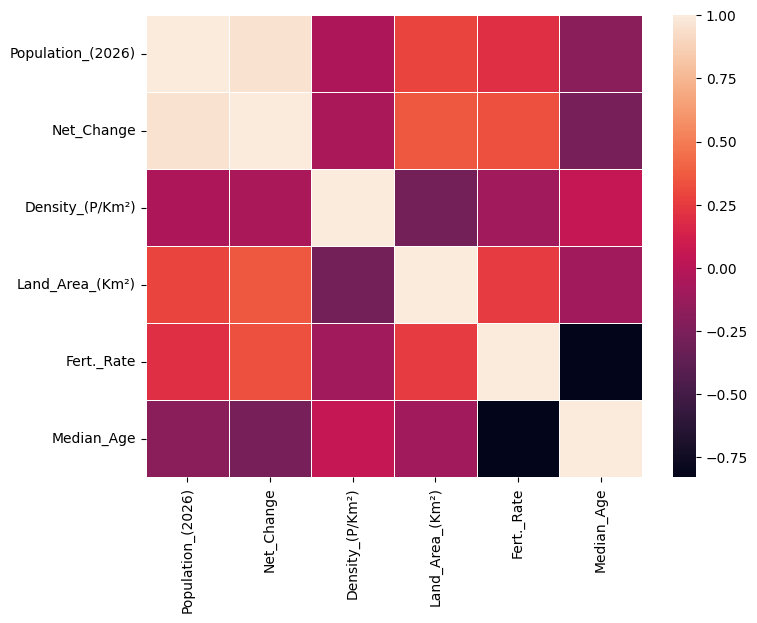

In [94]:
# Création du heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap='rocket', linewidths=0.5)

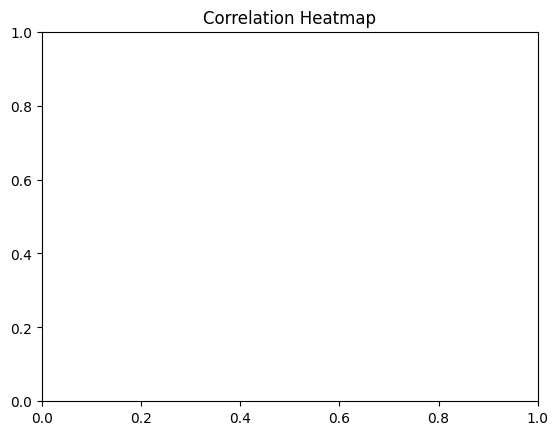

In [95]:
plt.title("Correlation Heatmap")
plt.show()

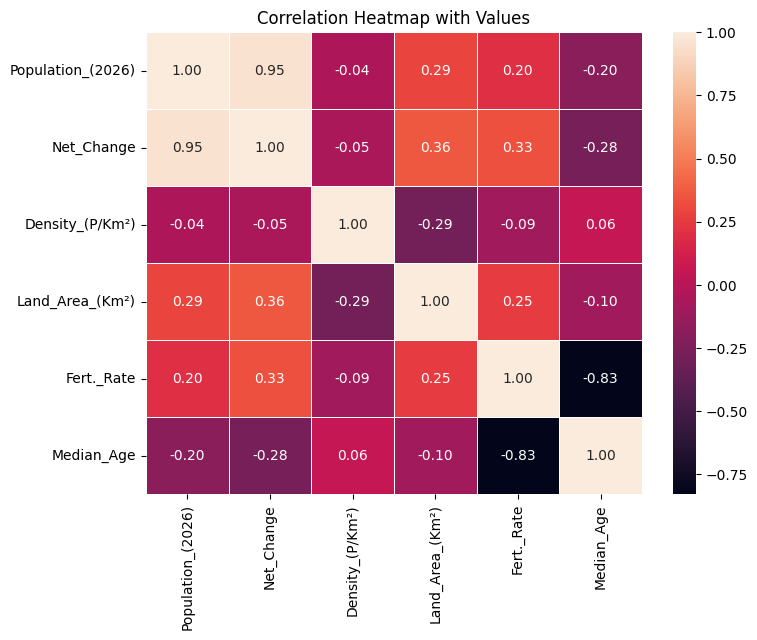

In [96]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='rocket', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap with Values")
plt.show()

In [99]:
df.to_csv("clean_aficapop2.csv", index=False)